# Beginner Tutorial: Image Segmentation with Random Forest
Welcome! This notebook teaches a **classical machine learning** approach to image segmentation.

In this tutorial, each pixel is classified as either:
- **0 = background**
- **1 = foreground**

We use:
- `scikit-image` to compute pixel-level features
- `scikit-learn` `RandomForestClassifier` to classify pixels
- **IoU (Intersection over Union)** to evaluate mask quality

---
## Learning goals
By the end, you should understand:
1. How to build a train/validation/test split for segmentation.
2. How handcrafted features can represent image texture and intensity.
3. Why threshold tuning matters for probability outputs.
4. How to evaluate and visualize segmentation predictions.

In [ ]:
# Random Forest Image Segmentation Tutorial (beginner-friendly code version)
#
# What this notebook does:
# 1) Reads RGB bean images + binary masks.
# 2) Extracts per-pixel handcrafted features with scikit-image.
# 3) Trains a RandomForest classifier to label each pixel as foreground/background.
# 4) Tunes a probability threshold on validation images.
# 5) Reports IoU on test images and saves predicted masks.

import os  # file and folder utilities
import numpy as np  # numerical arrays and random operations
import matplotlib.pyplot as plt  # visualization of predictions
from PIL import Image  # reading and resizing .tif/.tiff images
from skimage import feature  # feature extraction (multiscale texture/intensity)
from sklearn.ensemble import RandomForestClassifier  # classical ML classifier for segmentation

## Step 1 — Import libraries
The code cell above imports everything needed for the full workflow.

### Why these libraries?
- `numpy`: array operations
- `PIL`: image loading/resizing
- `skimage.feature`: handcrafted feature extraction
- `RandomForestClassifier`: supervised pixel classification
- `matplotlib`: prediction visualization

If this is your first run after opening the notebook, execute cells from top to bottom.

In [ ]:
# ----------------------------
# Configuration
# ----------------------------
# Folder containing RGB input images (.tif/.tiff).
IMAGE_DIR = "BeanBucketImages"
# Folder containing binary ground-truth masks (.tif/.tiff).
MASK_DIR  = "BeanBucketMasks_Otsu"

# Every image/mask will be resized to this shape before processing.
# PIL expects (width, height).
IMG_SIZE  = (256, 256)

# To keep training fast, we randomly sample this many pixels per training image.
# (Using all pixels can be very large for big datasets.)
PIXELS_PER_IMAGE = 1500

# Feature scales for multiscale features: smaller captures local detail,
# larger captures broader texture patterns.
sigma_min, sigma_max = 1, 16

# Data split ratios by image (NOT by pixel).
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# Fixed seed for reproducibility (same split + sampling every run).
RANDOM_SEED = 0

# We tune the final binary decision threshold on the validation set.
# The model outputs probabilities; threshold converts probability -> 0/1 mask.
THRESHOLDS = np.linspace(0.2, 0.8, 13)

# Number of test examples to visualize.
NUM_PREVIEW_TEST = 3

# Folder where predicted TEST masks will be saved as .png files.
OUT_DIR = "BeanBucketPredMasks_RF_TEST"

## Step 2 — Configure paths and hyperparameters
The previous code cell defines all settings in one place so beginners can tweak values safely.

### Parameters you can experiment with
- `IMG_SIZE`: larger sizes keep detail but increase runtime/memory
- `PIXELS_PER_IMAGE`: more sampled pixels usually improve stability
- `sigma_min/sigma_max`: controls feature scales
- split fractions: control train/val/test size

Tip: change only one setting at a time and compare IoU.

In [ ]:
# ----------------------------
# Helper functions
# ----------------------------
def load_img(path):
    """Load an RGB image and resize it to IMG_SIZE."""
    return np.array(Image.open(path).convert("RGB").resize(IMG_SIZE))

def load_mask(path):
    """Load a grayscale mask and resize with nearest-neighbor interpolation.

    Nearest-neighbor is important for masks so we do not create intermediate
    label values during resizing.
    """
    return np.array(Image.open(path).convert("L").resize(IMG_SIZE, Image.NEAREST))

def compute_iou(pred_bin, gt_bin):
    """Compute Intersection over Union (IoU) for binary masks.

    IoU = intersection / union.
    If both masks are empty, we define IoU as 1.0.
    """
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return 1.0 if union == 0 else inter / union

def predict_proba_fg(img_rgb, clf):
    """Return per-pixel foreground probability using trained classifier."""
    # Compute handcrafted multiscale features per pixel.
    feats = feature.multiscale_basic_features(
        img_rgb,
        intensity=True,
        edges=False,
        texture=True,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
        channel_axis=-1,
    )
    # Flatten HxWxF -> (H*W)xF for scikit-learn.
    X = feats.reshape(-1, feats.shape[-1])
    # Keep probability for class 1 (foreground), then reshape back to image grid.
    proba = clf.predict_proba(X)[:, 1].reshape(img_rgb.shape[:2])
    return proba

## Step 3 — Define helper functions
These helper functions keep the rest of the notebook easy to read.

### Key idea
`predict_proba_fg(...)` returns a **probability map** for foreground, not a hard mask. Later we choose a threshold to turn that map into binary predictions.

In [ ]:
# ----------------------------
# Gather file names
# ----------------------------
# Sort files so image/mask pairing is deterministic by filename order.
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".tif", ".tiff"))])
mask_files  = sorted([f for f in os.listdir(MASK_DIR)  if f.lower().endswith((".tif", ".tiff"))])

# Basic safety check: same number of images and masks, and not empty.
assert len(image_files) == len(mask_files) and len(image_files) > 0, "Image/mask count mismatch or empty folders."

N = len(image_files)
print(f"Found {N} image/mask pairs.")

# ----------------------------
# Split data by image index
# ----------------------------
# We split by image (not by pixel) to avoid leakage between train/test.
rng = np.random.default_rng(RANDOM_SEED)
idx = np.arange(N)
rng.shuffle(idx)

n_train = int(round(TRAIN_FRAC * N))
n_val   = int(round(VAL_FRAC   * N))
n_test  = N - n_train - n_val

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

print(f"Split: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

Found 500 image/mask pairs.
Split: train=350, val=75, test=75


## Step 4 — Build data splits
This stage discovers files and creates train/validation/test image indices.

### Why split by image instead of pixel?
Pixels from the same image are highly correlated. If train and test include pixels from the same image, test performance can look unrealistically good.

In [ ]:
# ----------------------------
# Build training data (pixel sampling from TRAIN images only)
# ----------------------------
X_list, y_list = [], []

for k in train_idx:
    im_f = image_files[k]
    m_f  = mask_files[k]

    # Load one training image and its binary mask.
    img  = load_img(os.path.join(IMAGE_DIR, im_f))
    mask = load_mask(os.path.join(MASK_DIR,  m_f))
    y = (mask > 0).astype(np.uint8)  # Convert to {0,1}.

    # Extract per-pixel multiscale features from the image.
    feats = feature.multiscale_basic_features(
        img,
        intensity=True,
        edges=False,
        texture=True,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
        channel_axis=-1,
    )
    X = feats.reshape(-1, feats.shape[-1])  # (H*W, F)
    y = y.reshape(-1)                       # (H*W,)

    # Create a roughly balanced subset of foreground/background pixels.
    fg = np.flatnonzero(y == 1)
    bg = np.flatnonzero(y == 0)

    n = PIXELS_PER_IMAGE
    n_fg = min(len(fg), n // 2)
    n_bg = min(len(bg), n - n_fg)

    # If one class is scarce, fill remaining slots from the other class.
    if n_fg + n_bg < n:
        if len(fg) - n_fg > len(bg) - n_bg:
            n_fg = min(len(fg), n - n_bg)
        else:
            n_bg = min(len(bg), n - n_fg)

    sel = np.concatenate([
        rng.choice(fg, size=n_fg, replace=False) if n_fg else np.array([], dtype=int),
        rng.choice(bg, size=n_bg, replace=False) if n_bg else np.array([], dtype=int),
    ])
    rng.shuffle(sel)

    # Keep sampled pixels only (reduces memory and training time).
    X_list.append(X[sel])
    y_list.append(y[sel])

# Combine data from all training images into one matrix/label vector.
X_train = np.vstack(X_list)
y_train = np.concatenate(y_list)
print("Training X:", X_train.shape, "fg fraction:", float(y_train.mean()))

Training X: (525000, 45) fg fraction: 0.5


## Step 5 — Build sampled training pixels
Instead of using every pixel from every training image, we sample a manageable subset.

### Why sample pixels?
- Reduces runtime and memory use
- Keeps training practical on laptops
- Still captures diverse examples across images

A rough foreground/background balance is enforced to help the classifier learn both classes.

In [ ]:
# ----------------------------
# Train Random Forest classifier
# ----------------------------
# RandomForest learns decision rules that map pixel features -> class label.
clf = RandomForestClassifier(
    n_estimators=300,              # number of trees
    n_jobs=-1,                     # use all available CPU cores
    max_depth=15,                  # limit tree depth to reduce overfitting
    class_weight="balanced_subsample",  # helps when classes are imbalanced
    random_state=RANDOM_SEED,
 )

# Fit model on sampled training pixels.
clf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 6 — Train the Random Forest
The model learns rules from the sampled feature vectors and binary labels.

### Beginner note
Random Forest often works well out-of-the-box for structured features and is a strong baseline before moving to deep learning models.

In [ ]:
# ----------------------------
# Tune threshold on VALIDATION set using mean IoU
# ----------------------------
# Model outputs probabilities in [0,1]. We need a threshold to make binary masks.
best_t = None
best_iou = -1.0

for t in THRESHOLDS:
    ious = []
    for k in val_idx:
        img = load_img(os.path.join(IMAGE_DIR, image_files[k]))
        gt  = (load_mask(os.path.join(MASK_DIR, mask_files[k])) > 0).astype(np.uint8)

        proba = predict_proba_fg(img, clf)
        pred  = (proba >= t).astype(np.uint8)

        ious.append(compute_iou(pred, gt))

    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    if mean_iou > best_iou:
        best_iou = mean_iou
        best_t = float(t)

print(f"Best threshold on val: {best_t:.3f}  (mean IoU={best_iou:.4f})")

Best threshold on val: 0.450  (mean IoU=0.8912)


## Step 7 — Tune the probability threshold on validation data
The classifier predicts probabilities, but segmentation needs binary masks.

We test many thresholds and keep the one with the best mean validation IoU.

### Why not tune on test?
Using the test set for tuning leaks information and gives overly optimistic results.

In [ ]:
# ----------------------------
# Evaluate on TEST set (mean IoU)
# ----------------------------
# Important: test set is used only once here for final reporting.
test_ious = []
for k in test_idx:
    img = load_img(os.path.join(IMAGE_DIR, image_files[k]))
    gt  = (load_mask(os.path.join(MASK_DIR, mask_files[k])) > 0).astype(np.uint8)

    proba = predict_proba_fg(img, clf)
    pred  = (proba >= best_t).astype(np.uint8)

    test_ious.append(compute_iou(pred, gt))

test_mean_iou = float(np.mean(test_ious)) if len(test_ious) else float("nan")
test_std_iou  = float(np.std(test_ious))  if len(test_ious) else float("nan")
print(f"TEST mean IoU: {test_mean_iou:.4f}  (std={test_std_iou:.4f}, n={len(test_ious)})")

TEST mean IoU: 0.8933  (std=0.0409, n=75)


## Step 8 — Final evaluation on the test set
Now we evaluate once on unseen test images using the selected threshold.

Reported values:
- **mean IoU**: average segmentation quality
- **std IoU**: consistency across test images

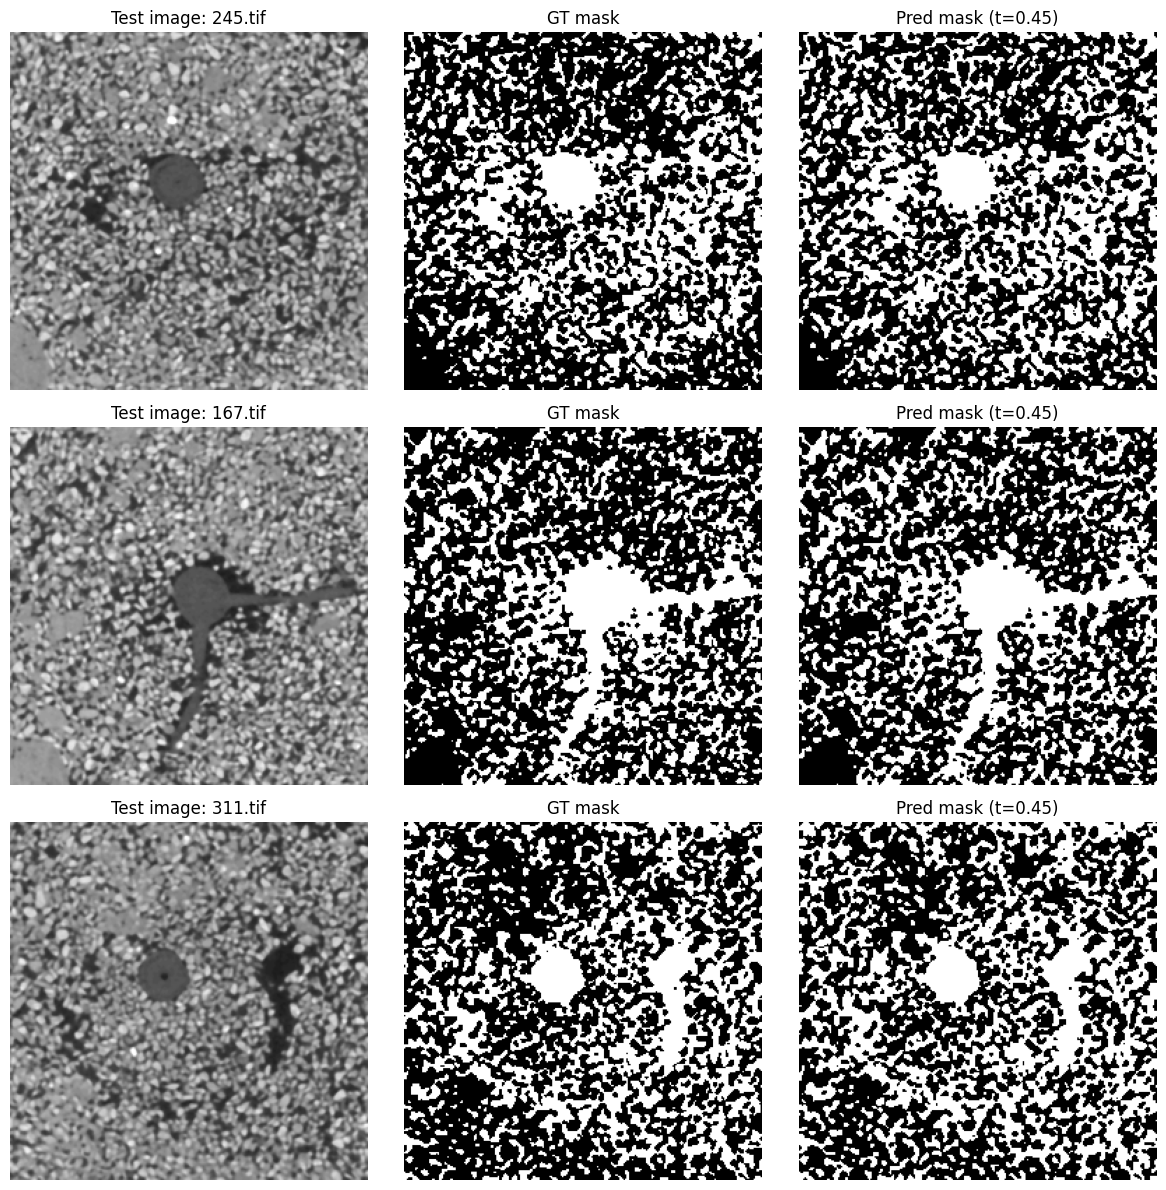

In [ ]:
# ----------------------------
# Preview a few TEST predictions (optional)
# ----------------------------
# Visual inspection helps you catch failure modes that a single metric might miss.
num_show = min(NUM_PREVIEW_TEST, len(test_idx))
if num_show > 0:
    fig, axes = plt.subplots(num_show, 3, figsize=(12, 4 * num_show))
    if num_show == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(num_show):
        k = test_idx[i]
        img = load_img(os.path.join(IMAGE_DIR, image_files[k]))
        gt  = (load_mask(os.path.join(MASK_DIR, mask_files[k])) > 0).astype(np.uint8)

        proba = predict_proba_fg(img, clf)
        pred  = (proba >= best_t).astype(np.uint8)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Test image: {image_files[k]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Ground-truth mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[i, 2].set_title(f"Predicted mask (threshold={best_t:.2f})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

## Step 9 — Visualize predictions
This comparison view (image / ground truth / prediction) helps explain model behavior to new learners.

When teaching, ask attendees:
- Where does the model over-segment?
- Where does it miss foreground?
- Do errors correlate with low contrast or texture?

In [ ]:
# ----------------------------
# Save predictions for TEST set
# ----------------------------
# We save each predicted mask using the original image base name.
os.makedirs(OUT_DIR, exist_ok=True)

for k in test_idx:
    im_f = image_files[k]

    img = load_img(os.path.join(IMAGE_DIR, im_f))
    proba = predict_proba_fg(img, clf)
    pred  = (proba >= best_t).astype(np.uint8)

    base, _ = os.path.splitext(im_f)
    out_path = os.path.join(OUT_DIR, base + ".png")
    Image.fromarray((pred * 255).astype(np.uint8)).save(out_path)

print("Saved TEST predictions to:", OUT_DIR)

Saved TEST predictions to: BeanBucketPredMasks_RF_TEST


## Step 10 — Save predicted masks
The last cell writes binary prediction masks for test images to disk.

These files can be used for:
- qualitative review
- downstream analysis
- side-by-side comparison with other segmentation methods

---
### Suggested exercises for first-time learners
1. Increase `PIXELS_PER_IMAGE` and observe runtime vs IoU.
2. Try a wider threshold grid.
3. Turn on `edges=True` in feature extraction and compare performance.
4. Compare this baseline with a U-Net model.